<a href="https://colab.research.google.com/github/chalonso/Cursor/blob/main/Proyecto_2_Optimizaci%C3%B3n_de_Precios_en_el_Mercado_Automotriz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏎️ Proyecto 2: Optimización de Precios en el Mercado Automotriz**

# **1. Contexto de Negocio**


Un marketplace de vehículos usados quiere optimizar su estrategia de precios y la arquitectura de sus filtros de búsqueda. El equipo de negocio tiene la hipótesis de que los autos que utilizan diésel son, en promedio, significativamente más caros que los de gasolina debido a su rendimiento de combustible. Sin embargo, no saben si esta diferencia es estadísticamente sólida o si está distorsionada por unos pocos autos de lujo.

Tu misión es determinar si existe una diferencia real y significativa entre los precios de ambos grupos para justificar estrategias de marketing y tasación diferenciadas.

# **2. Fundamento Estadístico (La Teoría)**


Para comparar las medias de dos grupos independientes, la herramienta estándar es la Prueba t de Student para muestras independientes. Sin embargo, esta prueba es exigente y requiere que se cumplan ciertos supuestos básicos antes de poder confiar en sus resultados:

Independencia: Las observaciones de un grupo no influyen en el otro (se cumple por el diseño de los datos).

Normalidad: Los datos de cada grupo deben seguir una distribución aproximadamente normal. Lo evaluaremos con la prueba de Shapiro-Wilk y gráficos Q-Q.

Homocedasticidad: Las varianzas de ambos grupos deben ser iguales. Lo evaluaremos con la prueba de Levene. Si las varianzas son muy diferentes, utilizaremos una variante llamada Prueba t de Welch.

Hipótesis Nula ($H_0$): No hay diferencia significativa entre el precio promedio de los autos a gasolina y los de diésel. ($\mu_{\text{gasolina}} = \mu_{\text{diésel}}$).

Hipótesis Alternativa ($H_1$): Existe una diferencia estadística significativa entre ambos precios promedio. ($\mu_{\text{gasolina}} \neq \mu_{\text{diésel}}$).

In [1]:
#Ingreso y Limpieza de datos

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración visual
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize']=[12,6]

#URL del data set en la UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"

# El dataset no tiene encabezados, los definimos manualmente para las columnas que nos importan
columnas = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
            'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
            'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
            'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
            'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Leer datos reemplazando '?' por NaN
df_autos = pd.read_csv(url, names=columnas, na_values="?")

In [2]:
# Filtrar para quedarnos solo con las columnas de interés y eliminar filas con precios nulos
df_analisis = df_autos[['fuel-type', 'price']].dropna().copy()

# Asegurar que el precio sea numérico
df_analisis['price'] = df_analisis['price'].astype(float)

print(f"📌 Dataset listo. Total de registros válidos: {df_analisis.shape[0]}")
print(df_analisis['fuel-type'].value_counts())

📌 Dataset listo. Total de registros válidos: 201
fuel-type
gas       181
diesel     20
Name: count, dtype: int64


**Paso 2: Análisis Exploratorio Visual (EDA)**


Vamos a ver cómo se distribuyen los precios usando un gráfico combinado de caja (boxplot) y dispersión (stripplot) para identificar valores atípicos (outliers).

Python

/tmp/ipykernel_2828/738436380.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel-type', y='price', data=df_analisis, palette="Set2",width=0.5)


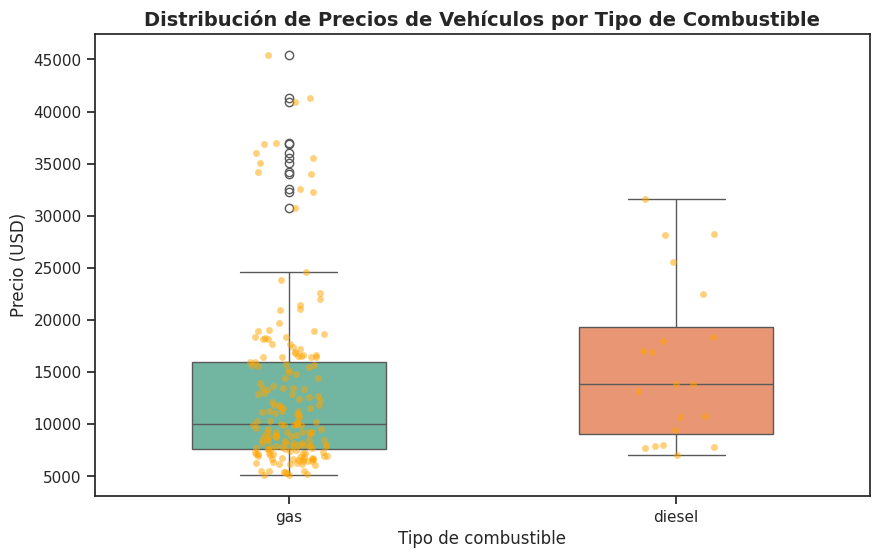


 Resumen estadistico por grupo:
           count         mean          std     min     25%      50%      75%  \
fuel-type                                                                      
diesel      20.0  15838.15000  7759.843713  7099.0  9120.0  13852.5  19375.5   
gas        181.0  12916.40884  7934.923212  5118.0  7609.0   9989.0  15985.0   

               max  
fuel-type           
diesel     31600.0  
gas        45400.0  


In [3]:
#Análisis exploratorio visual

plt.figure(figsize=(10,6))
sns.boxplot(x='fuel-type', y='price', data=df_analisis, palette="Set2",width=0.5)
sns.stripplot(x='fuel-type', y='price', data=df_analisis, color="orange",alpha=0.5)

plt.title('Distribución de Precios de Vehículos por Tipo de Combustible', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de combustible', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.show()

#Estadistico Descriptivo
print("\n Resumen estadistico por grupo:")
print(df_analisis.groupby('fuel-type')['price'].describe())


# **Paso 3: Validación de Supuestos Estadisticos (Filtro de calidad)**

Validaremos si los datos nos permiten usar la prueba t estándar.*texto en cursiva*

In [5]:
#Validación de supuestos

gasolina = df_analisis[df_analisis['fuel-type']=='gas']['price']
diesel = df_analisis[df_analisis['fuel-type']=='diesel']['price']

print("🔍 1. EVALUANDO NORMALIDAD (Shapiro-Wilk):")
#Nota: si p-valor < 0.05, los datos NO son normales
stat_g, p_g = stats.shapiro(gasolina)
stat_g, p_d = stats.shapiro(diesel)
print(f"Gasolina -> p-valor: {p_g:.8f} | {'No es normal' if p_g < 0.05 else 'Es normal'}")
print(f"Diésel    -> p-valor: {p_d:.8f} | {'No es normal' if p_d < 0.05 else 'Es normal'}")

print("\n 2. EVALUANDO HOMOCEDASTICIDAD (Prueba de Levene)")
#Nota si p-valor < 0.05 las varianzas son significativamente DIFERENTES
stat_l,  p_l = stats.levene(gasolina, diesel)
print(f"Levene Test -> p-valor: {p_l:.5f}")

🔍 1. EVALUANDO NORMALIDAD (Shapiro-Wilk):
Gasolina -> p-valor: 0.00000000 | No es normal
Diésel    -> p-valor: 0.03652640 | No es normal

 2. EVALUANDO HOMOCEDASTICIDAD (Prueba de Levene)
Levene Test -> p-valor: 0.55366
